363


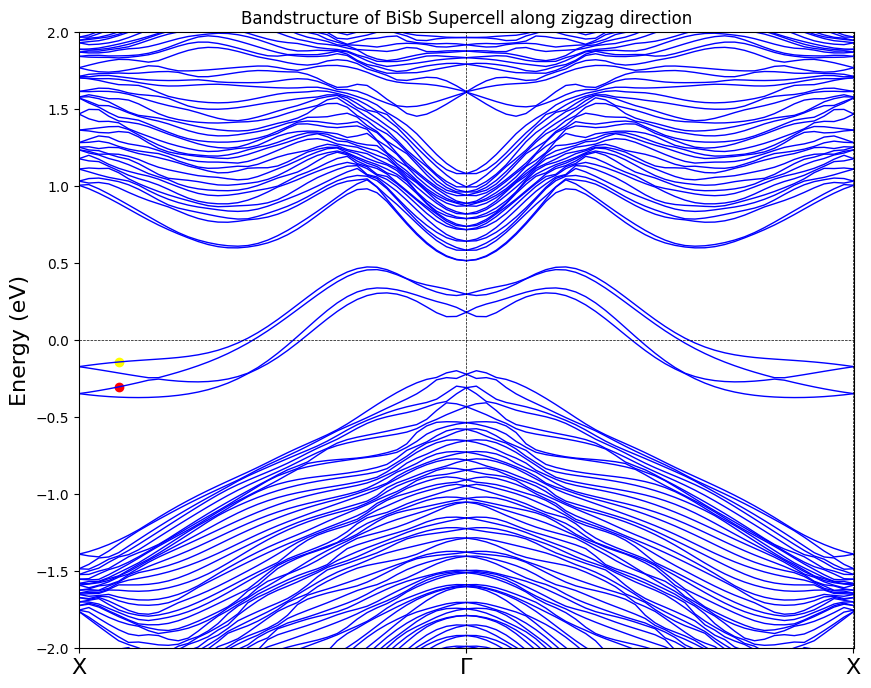

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)

high_symmetry_points = [0,0.737,1.474]  
high_symmetry_labels = ['X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue', lw=1)


plt.scatter(k[4],bands[4,299],color='red')

plt.scatter(k[4],bands[4,301],color='yellow')

plt.axhline(0, color='black', linestyle='--', lw=0.5)

for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)


plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.title("Bandstructure of BiSb Supercell along zigzag direction")
plt.ylabel('Energy (eV)', fontsize=16)
plt.ylim(-2, 2)
plt.xlim(min(k), max(k))
plt.savefig("nanoribbon_bandstructure.png", dpi=300, bbox_inches='tight')
plt.show()

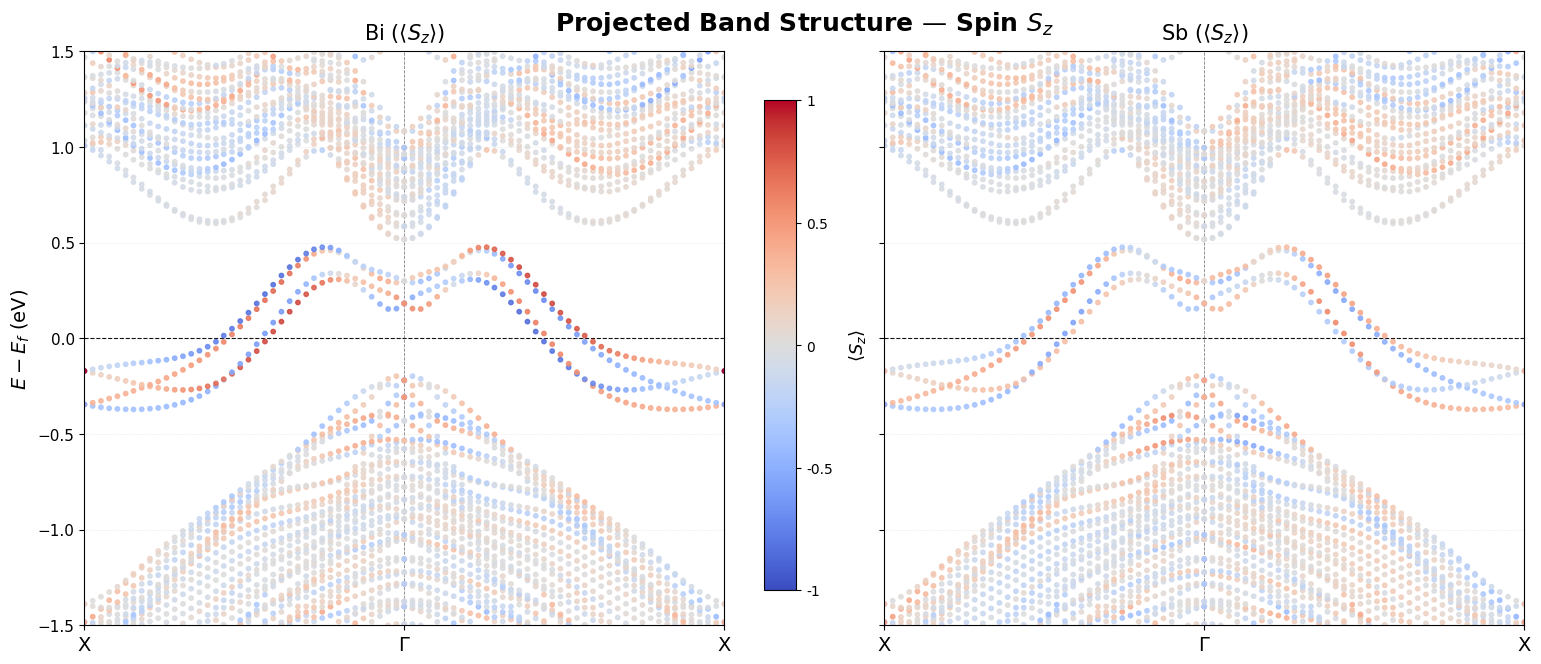

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load Data ---
def load_band_data(filepath):
    return pd.read_csv(filepath, comment='#', sep=r'\s+', header=None, skiprows=2)

data_bi = load_band_data("PBAND_Bi_SOC_SZ.dat")
data_sb = load_band_data("PBAND_Sb_SOC_SZ.dat")

k = data_bi[0].to_numpy()
e = data_bi[1].to_numpy()

# --- High-symmetry k-points and labels ---
k_points = [0,0.737,1.475]  
k_labels = ['X', r'$\Gamma$', 'X']

# --- Energy mask: apply BEFORE normalization ---
E_MASK_MIN, E_MASK_MAX = -1.5, 1.5   # adjust to taste

e_mask = (e >= E_MASK_MIN) & (e <= E_MASK_MAX)

spin_bi = data_bi[11].to_numpy()
spin_sb = data_sb[11].to_numpy()

# Compute absmax only within the energy window
global_absmax = max(np.abs(spin_bi[e_mask]).max(), np.abs(spin_sb[e_mask]).max())

spin_bi_norm = spin_bi[e_mask] / global_absmax
spin_sb_norm = spin_sb[e_mask] / global_absmax

k_masked = k[e_mask]
e_masked = e[e_mask]

# --- Shared norm and colormap ---
CMAP = 'coolwarm'
shared_norm = Normalize(vmin=-1, vmax=1)

# --- Plot ---
TITLES = [r'Bi ($\langle S_z \rangle$)', r'Sb ($\langle S_z \rangle$)']
spins  = [spin_bi_norm, spin_sb_norm]

fig = plt.figure(figsize=(16, 7))
fig.suptitle(r"Projected Band Structure — Spin $S_z$", fontsize=18, fontweight='bold')

ax_left  = fig.add_axes([0.05, 0.10, 0.40, 0.82])
ax_right = fig.add_axes([0.55, 0.10, 0.40, 0.82])
ax_cbar  = fig.add_axes([0.475, 0.15, 0.02, 0.70])

axes = [ax_left, ax_right]

for ax, spin, title in zip(axes, spins, TITLES):
    ax.scatter(k_masked, e_masked, c=spin, cmap=CMAP, s=10, norm=shared_norm, alpha=0.85, rasterized=True)

    for xv in k_points[1:-1]:
        ax.axvline(xv, ls='--', lw=0.6, color='gray', zorder=0)

    ax.axhline(0, ls='--', lw=0.8, color='black', zorder=0)
    ax.grid(True, which='major', linestyle=':', linewidth=0.4, alpha=0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlim(k_points[0], k_points[-1])
    ax.set_xticks(k_points)
    ax.set_xticklabels(k_labels, fontsize=14)
    ax.set_title(title, fontsize=15, pad=8)
    ax.tick_params(axis='y', labelsize=11)

ax_left.set_ylabel(r'$E - E_f$ (eV)', fontsize=14)
ax_right.set_yticklabels([])

# --- Centered colorbar ---
sm = ScalarMappable(cmap=CMAP, norm=shared_norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label(r'$\langle S_z \rangle$', fontsize=13, labelpad=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=10)

plt.savefig("spin_polarized_nanoribbon_bands.png", dpi=300, bbox_inches='tight')

plt.show()